In [223]:
!pip install xgboost


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [224]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import xgboost as xg
import matplotlib.pyplot as plt
from scipy.stats import hmean
import seaborn as sns

Load the data using 20,000 from each city, drop some attri
combine the 5 thing at the end

In [225]:
n = 30000
#order_id,accept_time,accept_gps_time,accept_gps_lng,
#accept_gps_lat,delivery_time,delivery_gps_time,delivery_gps_lng,delivery_gps_lat,ds

#accepted features : order_id, accept_time, dev_time, accept_long_gps, accept_lat_gps , dev_long_gps, dev_lat_gps 

drop_cols = ["region_id", "city", "aoi_id", "aoi_type","accept_gps_time", "delivery_gps_time"]

data_cq = pd.read_csv("LaDe/delivery/delivery_cq.csv").sample(n, random_state= 42).drop(columns=drop_cols)
data_hz = pd.read_csv("LaDe/delivery/delivery_hz.csv").sample(n, random_state= 42).drop(columns=drop_cols)
data_jl = pd.read_csv("LaDe/delivery/delivery_jl.csv").sample(n, random_state= 42).drop(columns=drop_cols)
data_sh = pd.read_csv("LaDe/delivery/delivery_sh.csv").sample(n, random_state= 42).drop(columns=drop_cols)
data_yt = pd.read_csv("LaDe/delivery/delivery_yt.csv").sample(n, random_state= 42).drop(columns=drop_cols)

total_data = pd.concat([data_cq,data_hz,data_jl,data_sh,data_yt], ignore_index= True)

critical = ["Order_id", "Lng", "Lat",
            "Accept_time", "Delivery_time"]

total_data.head(5)
len(total_data)

150000

remove dub by order_id, remove na, 

In [226]:

total_data = total_data.drop_duplicates(subset="order_id", keep="first")

critical = ["order_id", "lng", "lat", "accept_time", "delivery_time"]

total_data = total_data.dropna(subset=critical)
total_data.head(5)
len(total_data)

from numpy import radians, sin, cos, sqrt, arcsin

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    return 2 * R * arcsin(sqrt(a))

In [244]:
print(total_data["accept_time"].head(5))

print(total_data["delivery_time"].head(5))
total_data[""].max()


0    07-13 08:53:00
1    06-02 13:51:00
2    06-16 13:34:00
3    10-26 08:14:00
4    06-09 14:39:00
Name: accept_time, dtype: object
0    07-13 09:49:00
1    06-02 16:26:00
2    06-16 14:27:00
3    10-26 15:26:00
4    06-09 15:08:00
Name: delivery_time, dtype: object


'11-07 22:21:00'

remove base on outliers 

In [228]:

total_data["accept_time_dt"]   = pd.to_datetime(total_data["accept_time"], format="%m-%d %H:%M:%S")
total_data["delivery_time_dt"] = pd.to_datetime(total_data["delivery_time"], format="%m-%d %H:%M:%S")


total_data["hour"]        = total_data["accept_time_dt"].dt.hour
total_data["day_of_week"] = total_data["accept_time_dt"].dt.dayofweek

total_data["accept_time_dt"] = pd.to_datetime(total_data["accept_time"], format="%m-%d %H:%M:%S")


total_data["hour"] = total_data["accept_time_dt"].dt.hour

total_data["day_of_week"] = total_data["accept_time_dt"].dt.day_of_week

accept_gps_lng=total_data["accept_gps_lng"]
accept_gps_lat = total_data["accept_gps_lat"]
delivery_gps_lng = total_data["delivery_gps_lng"]
delivery_gps_lat =total_data["delivery_gps_lat"]

total_data["time_taken"] = (total_data["delivery_time_dt"] - total_data["accept_time_dt"]).dt.total_seconds() / 3600

total_data["distance"] = haversine(accept_gps_lat, accept_gps_lng, delivery_gps_lat, delivery_gps_lng)

total_data["speed"] = total_data["distance"] / total_data["time_taken"]

speed_clean = total_data["speed"][total_data["speed"] > 0].replace([np.inf, -np.inf], np.nan).dropna()

total_data["is_weekend"] = (total_data["day_of_week"] >= 5).astype(int)
# Two separate rush hour windows
total_data["is_morning_rush"] = total_data["hour"].isin([7, 8, 9, 10]).astype(int)
total_data["is_afternoon_rush"] = total_data["hour"].isin([13, 14, 15]).astype(int)
print(speed_clean)

0         5.581620
1         0.772266
2         1.198329
3         0.068738
4         4.109762
            ...   
149995    6.566862
149996    3.998357
149997    1.553866
149998    0.362609
149999    0.440773
Name: speed, Length: 148322, dtype: float64


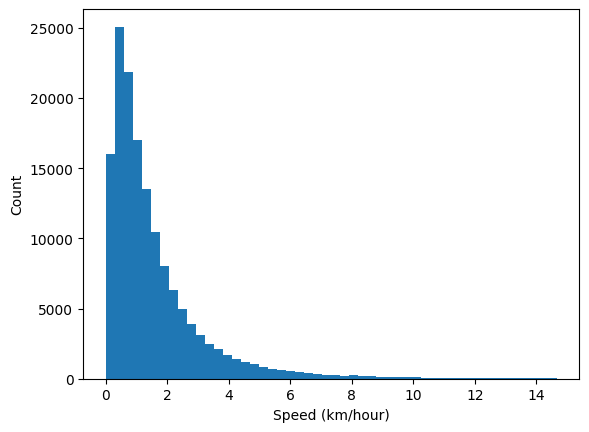

count    148322.000000
mean          4.364042
std         204.769843
min           0.000062
25%           0.540560
50%           1.065411
75%           2.023754
max       47399.707831
Name: speed, dtype: float64


In [229]:
cap = speed_clean.quantile(0.99) # this justt give cap the 1% data 
plt.hist(speed_clean[speed_clean < cap], bins=50) # Actaully doing it the if statement here is getting us the 99%
plt.xlabel("Speed (km/hour)")
plt.ylabel("Count")
plt.show()
print(speed_clean.describe())  


Why value is very low 
- sicne harvisine is just a straight line when calculating the kms, the actual road could be twice longer
- waiting for the merchant to prepare the order for the driver
- traffic lights elevators, finding the customer units  


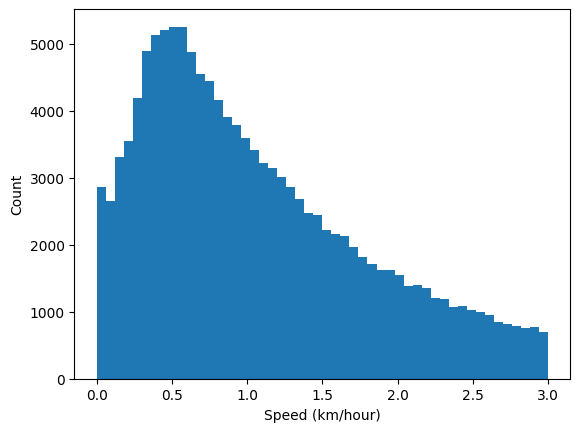

In [230]:
plt.hist(speed_clean[(speed_clean > 0) & (speed_clean < 3)], bins=50)
plt.xlabel("Speed (km/hour)")
plt.ylabel("Count")
plt.show()

THIS IS WHERE WE SPLIT THE DATA ITSELF from n = 100,000
60,000 as the train
20,000 crorss vali
20,000 teset

In [231]:
# X = total_data[["accept_gps_lng", "accept_gps_lat", "delivery_gps_lng", "delivery_gps_lat","hour","day_of_week","distance","time_taken","is_weekend","is_morning_rush","is_afternoon_rush"]].copy()

X = total_data[["accept_gps_lng", "accept_gps_lat", "delivery_gps_lng", "delivery_gps_lat","hour","day_of_week","distance","time_taken"]].copy()


#features
X = X.replace([np.inf, -np.inf], np.nan).dropna()
X = X[X["time_taken"] > 0]
X = X
y = X.pop("time_taken")

linear_model = LinearRegression()
print(total_data["time_taken"].describe())

count    150000.000000
mean          3.575761
std          12.091466
min           0.000000
25%           1.183333
50%           2.266667
75%           4.083333
max        1965.683333
Name: time_taken, dtype: float64


In [232]:

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

q1 = speed_clean.quantile(0.25)
q3 = speed_clean.quantile(0.75)

iqr = q3 - q1

print(f"The IQR {iqr}")

outlier_left = max(0, q1 - 1.5 * iqr) 

outlier_right= q3 + 3 * iqr

print(f"outlier left  {outlier_left}")

print(f"outlier right {outlier_right}")

# mask = y <= outlier_right and y > outlier_left 

mask = (y <= outlier_right) & (y >outlier_left)
X_clean = X[mask]
y_clean = y[mask]
ol = (~mask).sum()
print(f"Removed {(~mask).sum()} outliers")
print(f"Remaining: {mask.sum()} samples")

print(f"X_clean shape: {X_clean.shape}")
print(f"y_clean shape: {y_clean.shape}")
print(y_clean.describe())

The IQR 1.4831932462705995
outlier left  0
outlier right 6.473333297281695
Removed 15651 outliers
Remaining: 132674 samples
X_clean shape: (132674, 7)
y_clean shape: (132674,)
count    132674.000000
mean          2.336120
std           1.556812
min           0.016667
25%           1.083333
50%           2.000000
75%           3.350000
max           6.466667
Name: time_taken, dtype: float64


In [233]:
X_train, X_temp, y_train, y_temp = train_test_split(X_clean, y_clean, train_size=0.6, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, train_size=0.5, random_state=42)

linear_model.fit(X_train, y_train)

train_pred = linear_model.predict(X_train)
val_pred = linear_model.predict(X_val)
test_pred = linear_model.predict(X_test)

train_mse = mean_squared_error(y_train, train_pred)
val_mse = mean_squared_error(y_val, val_pred)
test_mse = mean_squared_error(y_test, test_pred)


print(f"Train MSE: {train_mse}") # W of train
print(f"Val MSE:   {val_mse}") # W of train 
print(f"Test MSE:  {test_mse}")# W of train 

print(f"Train RMSE: {np.sqrt(train_mse):.2f} hour")
print(f"Val RMSE:   {np.sqrt(val_mse):.2f} hour")
print(f"Test RMSE:  {np.sqrt(test_mse):.2f} hour")

lol = np.sqrt(test_mse)

print(f"y mean: {y_train.mean():.2f} hour")
print(f"y std:  {y_train.std():.2f} hour")
print(f"errRate : {lol/y_train.std()}")

Train MSE: 2.020878658351017
Val MSE:   2.0370537394722286
Test MSE:  2.0351667589520126
Train RMSE: 1.42 hour
Val RMSE:   1.43 hour
Test RMSE:  1.43 hour
y mean: 2.33 hour
y std:  1.56 hour
errRate : 0.9168365796391266



under 0.5  → great  
0.5 - 0.8  → okay   
above 0.8  → poor   

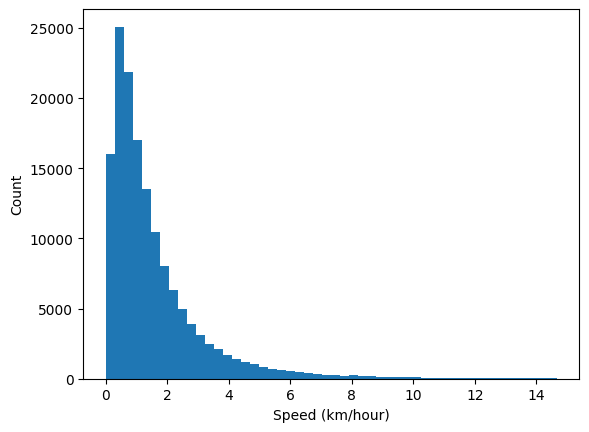

count    148322.000000
mean          4.364042
std         204.769843
min           0.000062
25%           0.540560
50%           1.065411
75%           2.023754
max       47399.707831
Name: speed, dtype: float64


In [234]:
cap = speed_clean.quantile(0.99) # this justt give cap the 1% data 
plt.hist(speed_clean[speed_clean < cap], bins=50) # Actaully doing it the if statement here is getting us the 99%
plt.xlabel("Speed (km/hour)")
plt.ylabel("Count")
plt.show()
print(speed_clean.describe())  

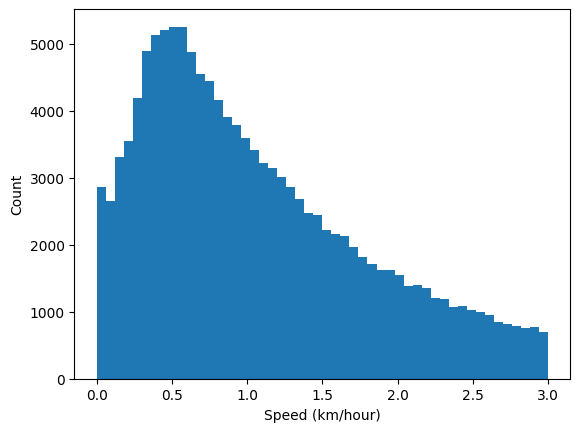

In [235]:
plt.hist(speed_clean[(speed_clean > 0) & (speed_clean < 3)], bins=50)
plt.xlabel("Speed (km/hour)")
plt.ylabel("Count")
plt.show()

In [236]:

print(y_train.describe())
print(y_val.describe())
print(y_test.describe())



count    79604.000000
mean         2.332268
std          1.555995
min          0.016667
25%          1.083333
50%          1.983333
75%          3.350000
max          6.466667
Name: time_taken, dtype: float64
count    26535.000000
mean         2.338160
std          1.562644
min          0.016667
25%          1.066667
50%          1.983333
75%          3.366667
max          6.466667
Name: time_taken, dtype: float64
count    26535.000000
mean         2.345637
std          1.553433
min          0.016667
25%          1.100000
50%          2.000000
75%          3.333333
max          6.466667
Name: time_taken, dtype: float64


Val MSE within ~10-15% of Train MSE → healthy, model generalizes well
Val MSE 2x+ Train MSE → overfitting
All three MSEs are high → underfitting, model isn't learning enough

In [237]:

print((y>17.5).sum())
     

2088


In [238]:
outlier_percen = ol/ 150000 * 100

print(f"outliers are percentage is {outlier_percen}")



outliers are percentage is 10.434000000000001


common outliers = mean + x3 standard deviation 

Note this above is onlly when the data is not skewed 

---

if the data is skewed the appropriate formula for it would be 

THE IQR FORMULA

the percentage that is responsible for outlier good percentage would be 0.3% for a data that is not skewed

if the data is heabily skwered 

heavily skewed  = maybe 3-10% is still okay

In [239]:

print(f"errRate : {lol/y_train.std()}")

errRate : 0.9168365796391266


In [240]:
import xgboost as xg

# Create model
xgb_model = xg.XGBRegressor(
    n_estimators=1000,      # number of trees
    learning_rate=0.05,     # how fast it learns
    max_depth=6,           # tree depth
    random_state=42
)

# Train
xgb_model.fit(X_train, y_train)

# Predict
train_pred = xgb_model.predict(X_train)
val_pred   = xgb_model.predict(X_val)
test_pred  = xgb_model.predict(X_test)

# RMSE
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
val_rmse   = np.sqrt(mean_squared_error(y_val, val_pred))
test_rmse  = np.sqrt(mean_squared_error(y_test, test_pred))

print(f"Train RMSE: {train_rmse:.2f}")
print(f"Val RMSE:   {val_rmse:.2f}")
print(f"Test RMSE:  {test_rmse:.2f}")

err_rate = test_rmse / y_train.std()
print(f"errRate: {err_rate:.2f}")



Train RMSE: 1.07
Val RMSE:   1.19
Test RMSE:  1.19
errRate: 0.76


In [241]:
from sklearn.ensemble import RandomForestRegressor

randomForestModel = RandomForestRegressor(
    n_estimators=300,       
    max_depth=None,            
    min_samples_split=5,    
    min_samples_leaf=2,      
    max_features=0.5,     
    random_state=42,
    n_jobs=-1
)
# {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': None}
randomForestModel.fit(X_train,y_train)

train_pred = randomForestModel.predict(X_train)

train_val= randomForestModel.predict(X_val)
train_test= randomForestModel.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(train_pred,y_train))
val_rmse= np.sqrt(mean_squared_error(train_val,y_val))
test_rmse= np.sqrt(mean_squared_error(train_test,y_test))


print(f"Train RMSE: {train_rmse:.4f}")
print(f"Val RMSE:   {val_rmse:.4f}")
print(f"Test RMSE:  {test_rmse:.4f}")

err_rate = test_rmse / y_train.std()


Train RMSE: 0.6207
Val RMSE:   1.1467
Test RMSE:  1.1490


In [242]:
print(err_rate)

0.7384059951304435


In [243]:
from sklearn.ensemble import ExtraTreesRegressor

# Create model
et_model = ExtraTreesRegressor(
    n_estimators=1000,
    max_depth=6,
    random_state=42,
    n_jobs= -1
)

# Train
et_model.fit(X_train, y_train)

# Predict
train_pred = et_model.predict(X_train)
val_pred   = et_model.predict(X_val)
test_pred  = et_model.predict(X_test)

# RMSE
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
val_rmse   = np.sqrt(mean_squared_error(y_val, val_pred))
test_rmse  = np.sqrt(mean_squared_error(y_test, test_pred))

print(f"Train RMSE: {train_rmse:.2f}")
print(f"Val RMSE:   {val_rmse:.2f}")
print(f"Test RMSE:  {test_rmse:.2f}")

err_rate = test_rmse / y_train.std()
print(f"errRate: {err_rate:.2f}")

Train RMSE: 1.37
Val RMSE:   1.38
Test RMSE:  1.37
errRate: 0.88
